教師あり機械学習

In [16]:
import pandas as pd

df = pd.read_excel('boston_clean.xlsx')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


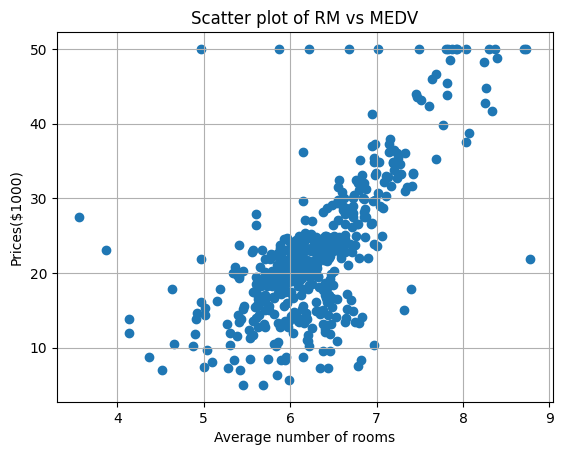

In [17]:
import matplotlib.pyplot as plt

plt.scatter(df['RM'],
            df['MEDV'])
# 住宅の部屋数「RM」と住宅価格「MEDV」の値を参考に散布図を作成
plt.title('Scatter plot of RM vs MEDV')
plt.xlabel('Average number of rooms')
plt.ylabel('Prices($1000)')
plt.grid()
plt.show()
# 散布図が正の相関になっていることが分かる

In [22]:
x = df[['RM']]
y = df['MEDV']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size = 0.7, test_size = 0.3, random_state = 0)

単回帰分析(1つの変数を使って目的変数の値を直線的に予測するアルゴリズム)

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
print('intercept = ', model.intercept_)
print(pd.DataFrame({"Name":x_train.columns, "Coefficients":model.coef_}).sort_values(by='Coefficients'))

intercept =  -35.99434897818352
  Name  Coefficients
0   RM      9.311328


説明変数：部屋数　目的変数：住宅価格

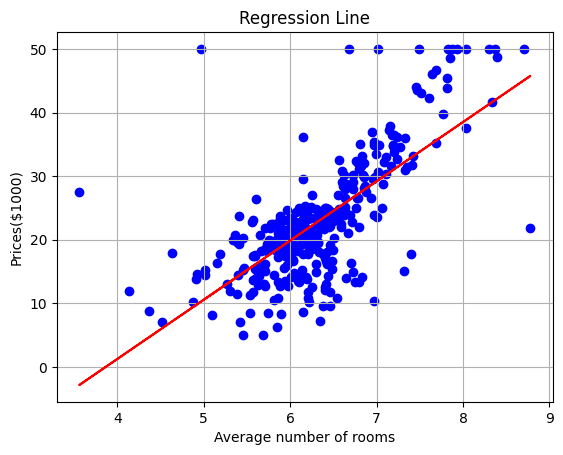

In [25]:
import matplotlib.pyplot as plt

plt.scatter(x_train, y_train, color = 'blue')
plt.plot(x_train, model.predict(x_train), color = 'red')
plt.title('Regression Line')
plt.xlabel('Average number of rooms')
plt.ylabel('Prices($1000)')
plt.grid()
plt.show()
# 部屋数と住宅価格の関係性を直線で表している

以下のプログラムで学習データとテストデータに関する住宅価格の予測精度を確認できる

In [26]:
from sklearn.metrics import r2_score
print('r^2 (train):',r2_score(y_train, model.predict(x_train)))
print('r^2 (test):',r2_score(y_test, model.predict(x_test)))
# 表示される数値は決定変数(1に近いほど予測精度が高いことを表す)
# 学習データの決定変数は0.5　テストデータの決定変数は0.43
# 決定変数が0.6を下回る回帰AIはあまり使い物にならない

r^2 (train): 0.5026497630040827
r^2 (test): 0.43514364832115193


単回帰分析で作成した回帰AIで、部屋数が10の時の住宅価格を予測してみる

In [27]:
df_pred = pd.DataFrame([10], columns=['RM'])
x_pred = df_pred[['RM']]

y_pred = model.predict(x_pred)
print(y_pred[0])

57.11893165433501


重回帰分析で住宅価格の予測を行う

複数の情報を用いて予測を行う場合、単位の異なる情報を区別して考える必要があるため、標準化を行う

標準化とは各説明変数の平均と標準偏差を使って、各説明変数の平均を0、分散を1にするという操作のこと

In [28]:
x = df.drop('MEDV', axis = 1) # MEDVを除いたすべての列の説明変数
y = df['MEDV']

from sklearn.preprocessing import StandardScaler # 標準化を行うための機能

scaler = StandardScaler()
scaler.fit(x)
x_std = scaler.transform(x)
x_std = pd.DataFrame(x_std)
x_std.columns = x.columns

x_train, x_test, y_train, y_test = train_test_split(
    x_std, y, train_size = 0.7, test_size = 0.3, random_state = 0)

重回帰分析を行うときのプログラムは単回帰分析と同じ

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)
print('intercept =', model.intercept_)
print(pd.DataFrame({"Name":x_train.columns,"Coefficients":model.coef_}).sort_values(by='Coefficients'))

intercept = 22.456310064174726
       Name  Coefficients
12    LSTAT     -3.472390
7       DIS     -3.156010
10  PTRATIO     -2.201201
4       NOX     -1.878980
9       TAX     -1.864133
0      CRIM     -1.042425
6       AGE     -0.280793
2     INDUS      0.077731
11        B      0.621511
3      CHAS      0.637211
1        ZN      1.036041
8       RAD      2.106322
5        RM      2.708767


13種類の説明変数を考慮した回帰AIが作成されている(高速道路のアクセスのしやすさや部屋数に応じて住宅価格の変動を表している)

In [30]:
from sklearn.metrics import r2_score

print('r^2 (train):', r2_score(y_train, model.predict(x_train)))
print('r^2 (test):', r2_score(y_test, model.predict(x_test)))

r^2 (train): 0.7645451026942549
r^2 (test): 0.6733825506400196
